<a href="https://colab.research.google.com/github/Astrages4/ML_labs/blob/main/lab3/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №3
Изображения и видео

Импортируем библиотеки:

In [2]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.0 MB/s eta 0:00:00


In [3]:
import cv2
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import xml.etree.ElementTree as ET
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Декодирование видео в последовательность кадров

In [6]:
input_video = "/content/drive/MyDrive/input.mp4"
output_video = "/content/drive/MyDrive/output.mp4"
xml_path = "/content/drive/MyDrive/annotations.xml"
frames_input = "/content/drive/MyDrive/input_frames"
frames_output = "/content/drive/MyDrive/output_frames"
COCO_annotations = "annotations.json"

def extract_frames(video_path, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_name = os.path.join(output_dir, f"frame_{count:04d}.jpg")
        cv2.imwrite(frame_name, frame)
        count += 1

    cap.release()
    print(f"{video_path}: Сохранено {count} кадров")
    return count

num_frames = extract_frames(input_video, frames_input)
_ = extract_frames(output_video, frames_output)

/content/drive/MyDrive/input.mp4: Сохранено 301 кадров
/content/drive/MyDrive/output.mp4: Сохранено 301 кадров


## Извлечение bounding box (bbox)
Теперь нужно извлечь уже существующую разметку из видео, т.е. нужно как-то считать цветные контуры.
Сделаем это двумя способами: методом глобальной пороговой бинаризации и методом детекции границ Canny. Затем сравним результаты.

In [7]:
# метод границ Canny
def extract_bboxes_canny(in_frame_path, out_frame_path):
    img_in, img_out = cv2.imread(in_frame_path), cv2.imread(out_frame_path)
    if img_in is None or img_out is None:
        return []

    diff = cv2.absdiff(img_in, img_out)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    dilated = cv2.dilate(edges, np.ones((5, 5), np.uint8), iterations=1)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bboxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 20 and h > 20:
            bboxes.append([x, y, x + w, y + h])
    return bboxes

# метод бинризации
def extract_bboxes_binary(in_frame_path, out_frame_path):
    img_in, img_out = cv2.imread(in_frame_path), cv2.imread(out_frame_path)
    if img_in is None or img_out is None:
        return []

    diff = cv2.absdiff(img_in, img_out)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bboxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 20 and h > 20:
            bboxes.append([x, y, x + w, y + h])
    return bboxes


Функции для iou:

In [8]:
def calculate_iou(boxA, boxB):
    xA, yA, xB, yB = (
        max(boxA[0], boxB[0]),
        max(boxA[1], boxB[1]),
        min(boxA[2], boxB[2]),
        min(boxA[3], boxB[3]),
    )
    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0
    return interArea / float(
        ((boxA[2] - boxA[0]) * (boxA[3] - boxA[1]))
        + ((boxB[2] - boxB[0]) * (boxB[3] - boxB[1]))
        - interArea
    )

def get_max_iou(pred_box, gt_boxes):
    return (
        max([calculate_iou(pred_box, gt) for gt in gt_boxes])
        if gt_boxes
        else 0.0
    )

## Сравнительный анализ
Чтобы выбрать лучший метод, но не ждать слишком долго, рассмотрим работу обоих методов на одних и тех же кадрах. Посмтрим как метрики, так и как выглядят найденные рамки в кадре.

Кадр 50
Найдено машин в XML: 10
Метод бинаризации: найдено рамок: 9, средний IoU: 0.5905
Метод фильтр Canny: найдено рамок: 9, средний IoU: 0.5679



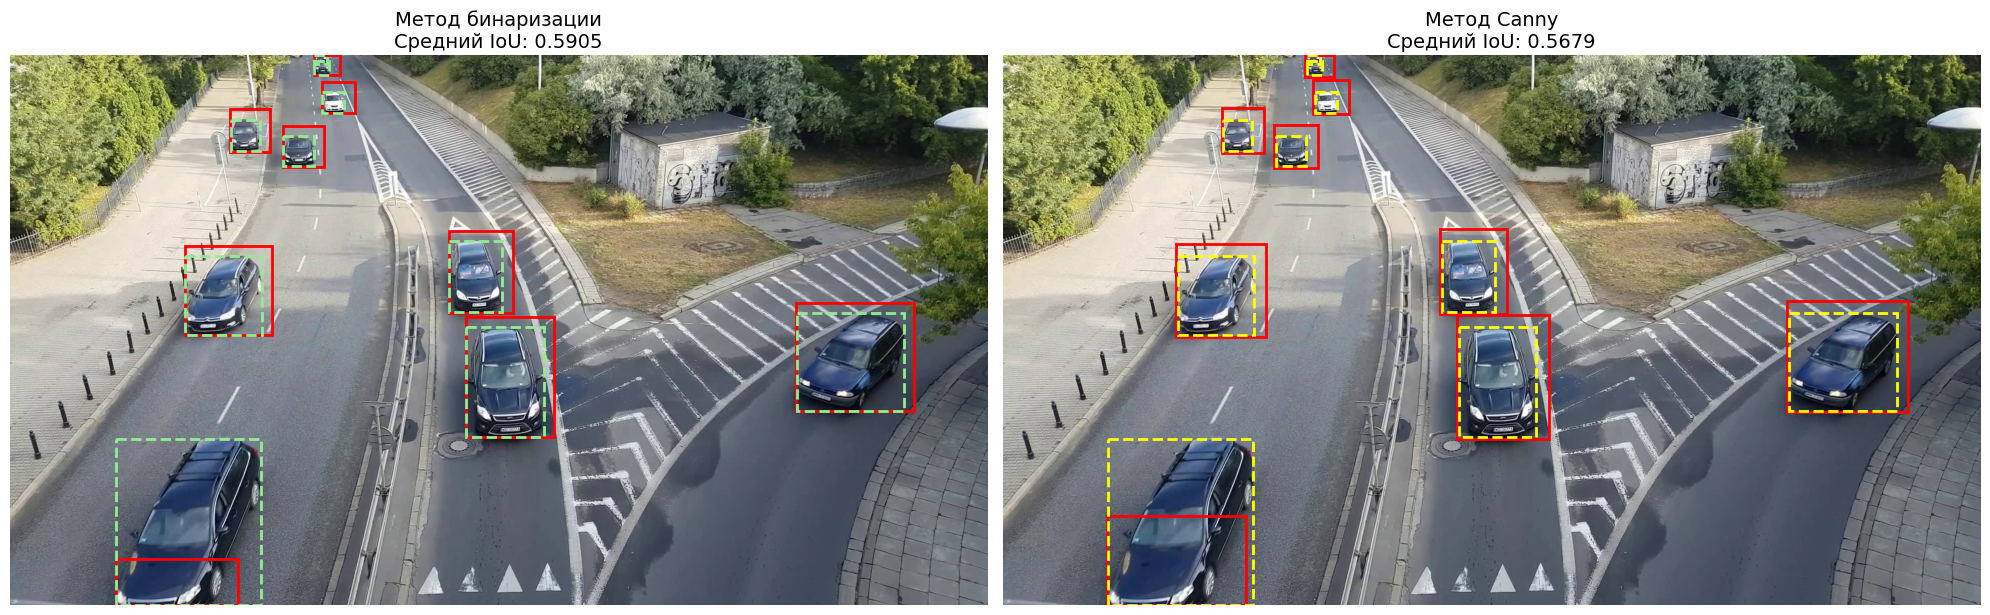

Кадр 88
Найдено машин в XML: 10
Метод бинаризации: найдено рамок: 8, средний IoU: 0.4843
Метод фильтр Canny: найдено рамок: 7, средний IoU: 0.4646



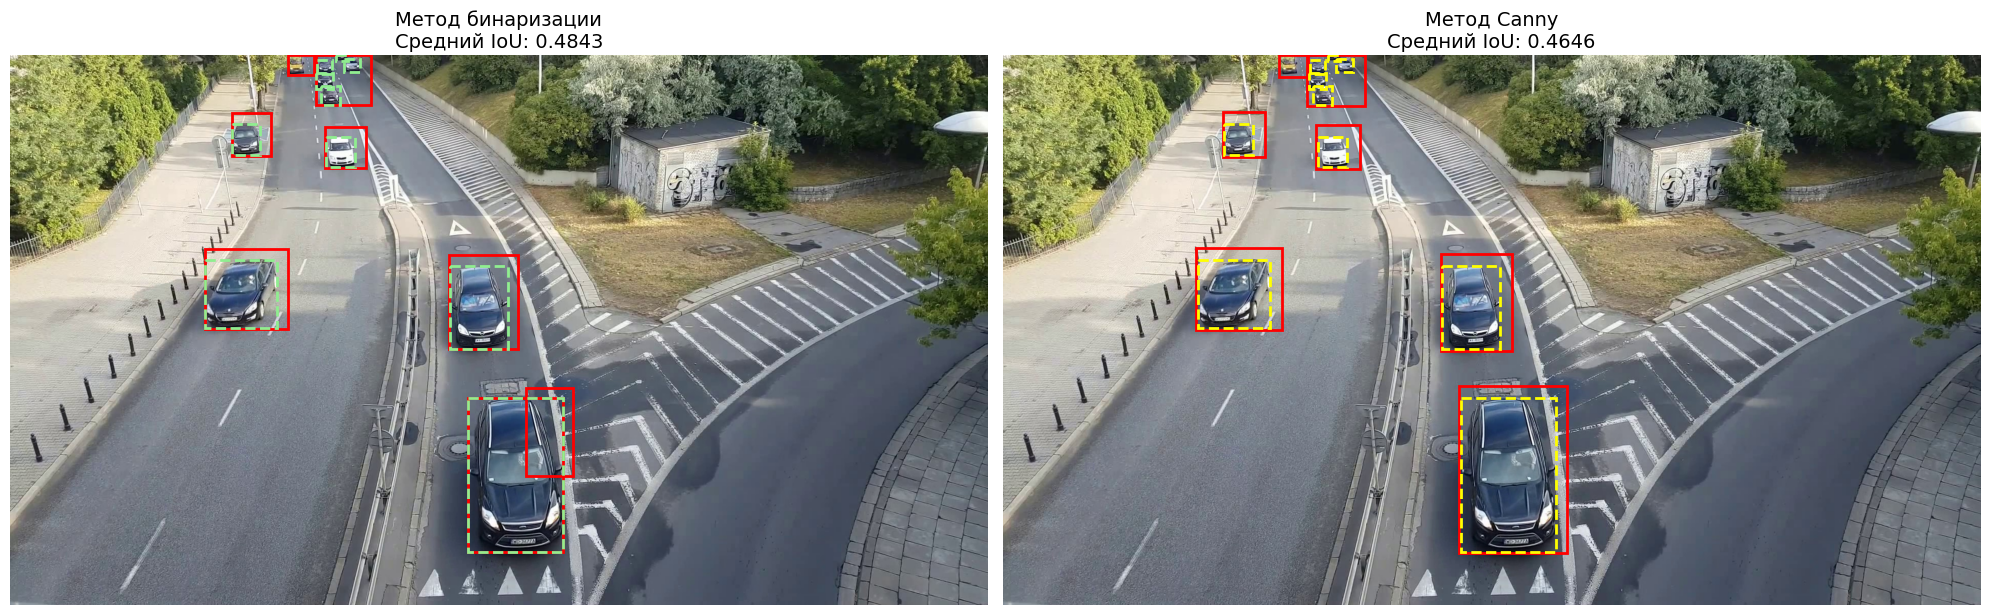

Кадр 100
Найдено машин в XML: 11
Метод бинаризации: найдено рамок: 7, средний IoU: 0.5018
Метод фильтр Canny: найдено рамок: 6, средний IoU: 0.5615



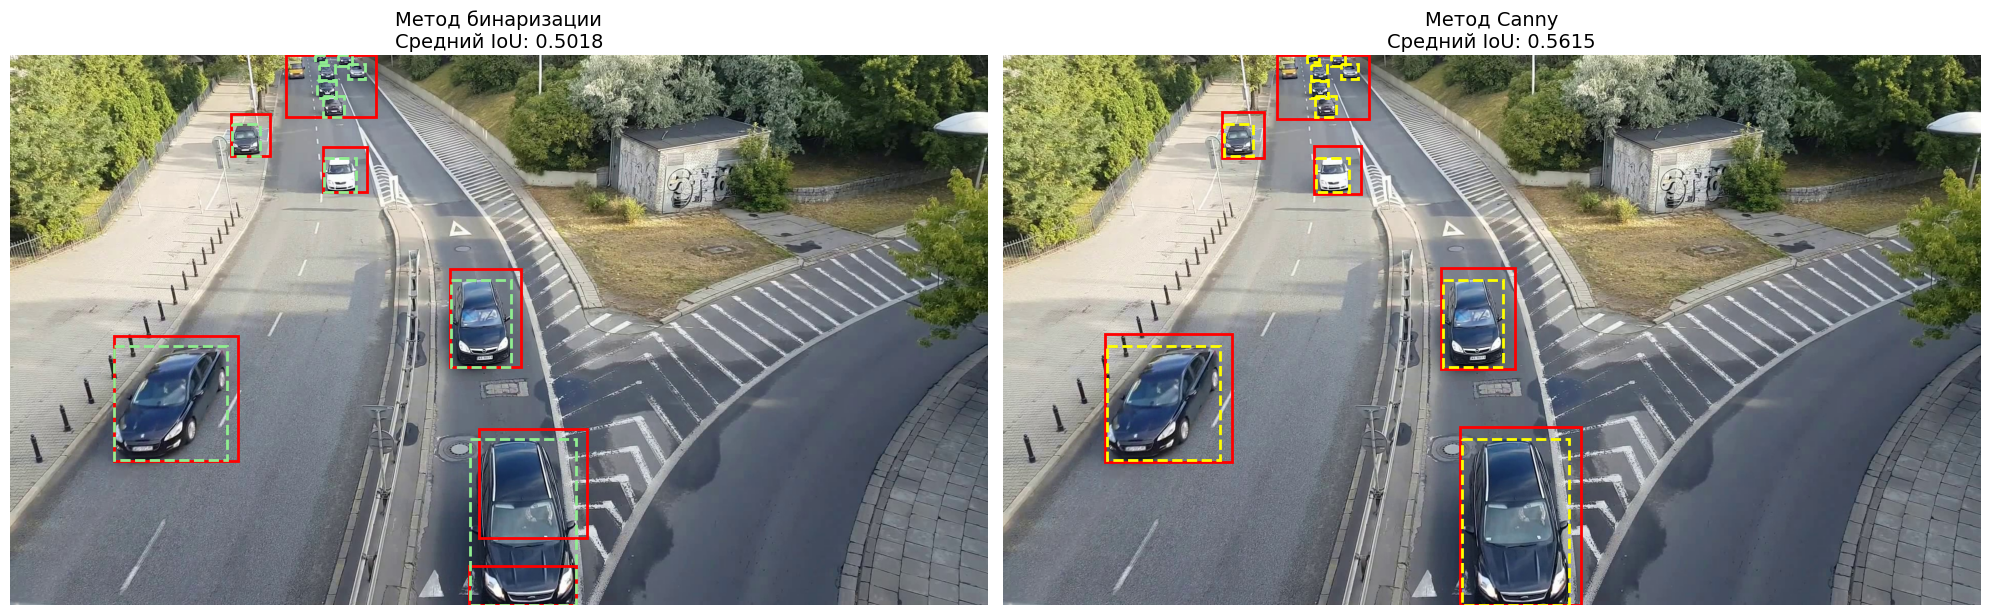

Кадр 150
Найдено машин в XML: 13
Метод бинаризации: найдено рамок: 7, средний IoU: 0.4904
Метод фильтр Canny: найдено рамок: 6, средний IoU: 0.4518



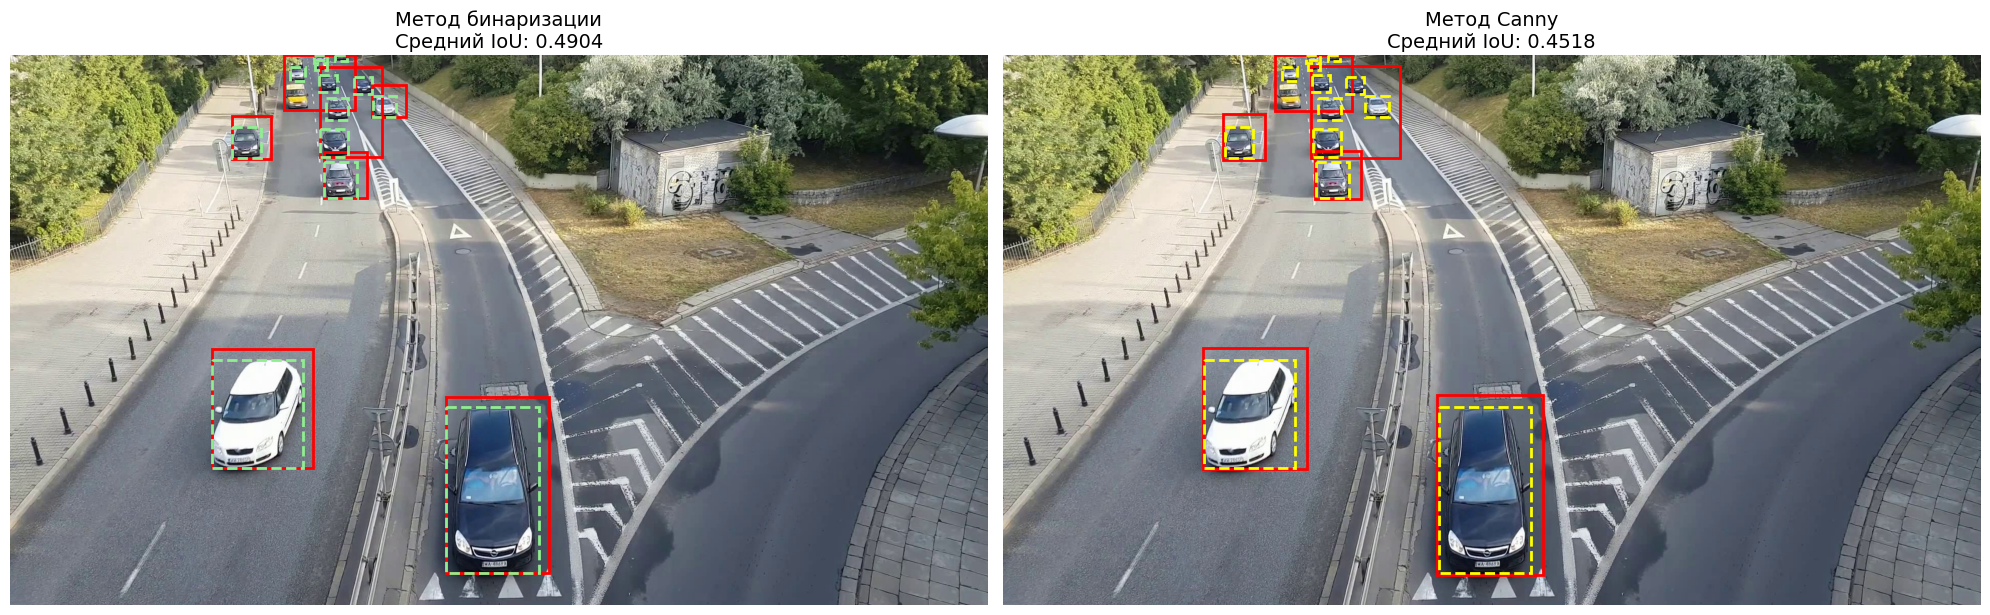

Кадр 200
Найдено машин в XML: 14
Метод бинаризации: найдено рамок: 10, средний IoU: 0.4685
Метод фильтр Canny: найдено рамок: 9, средний IoU: 0.4301



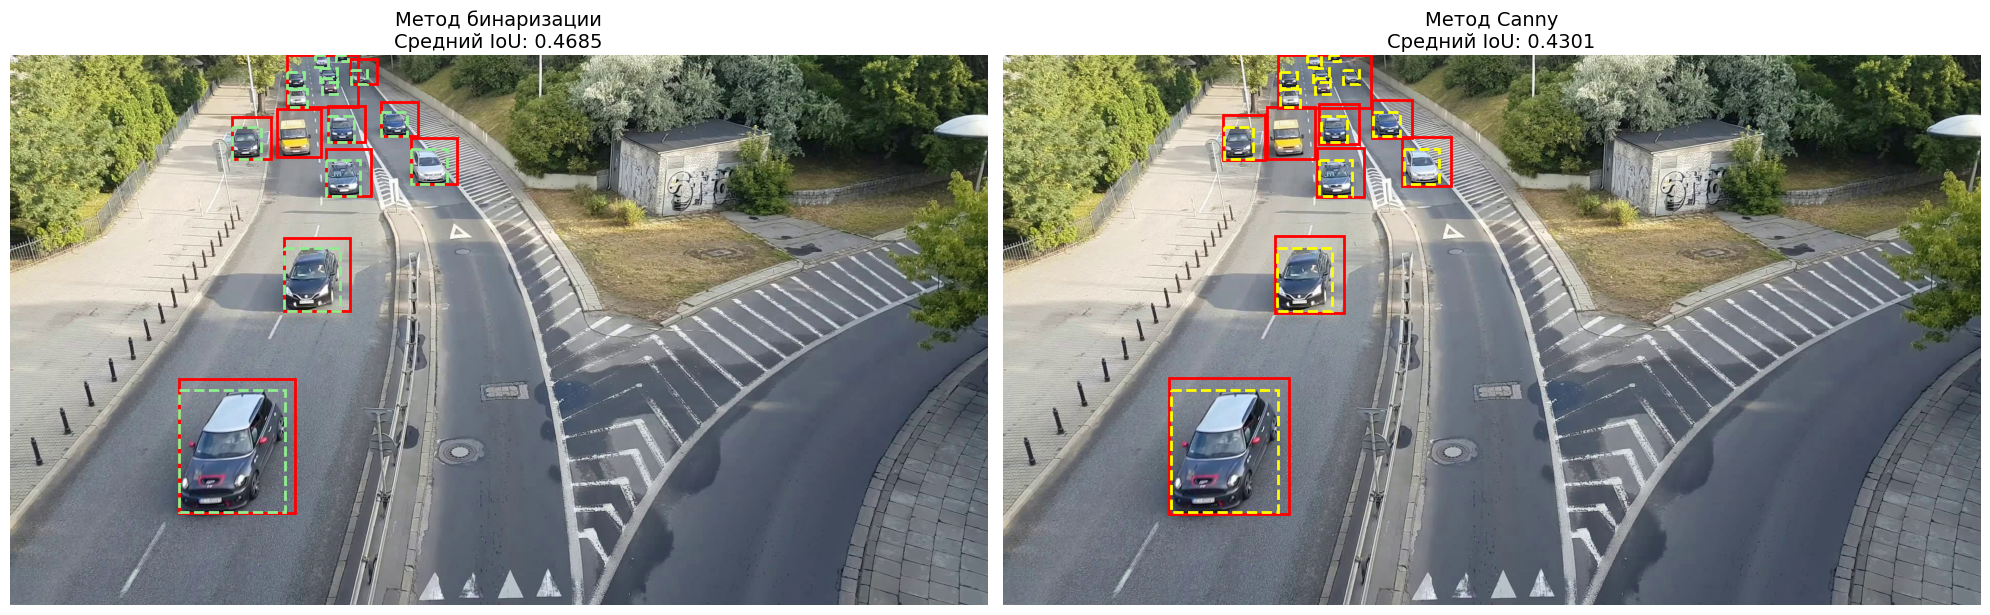

In [9]:
test_frames = [50, 88, 100, 150, 200]
for test_frame in test_frames:
    in_path = os.path.join(frames_input, f"frame_{test_frame:04d}.jpg")
    out_path = os.path.join(frames_output, f"frame_{test_frame:04d}.jpg")

    boxes_thresh = extract_bboxes_binary(in_path, out_path)
    boxes_canny = extract_bboxes_canny(in_path, out_path)

    # исходные данные (эталон)
    tree = ET.parse(xml_path)
    gt_boxes = []

    for track in tree.getroot().findall("track"):
        if track.get("label") == "car":
            box = track.find(f".//box[@frame='{test_frame}']")
            if box is not None:
                gt_boxes.append(
                    [
                        float(box.get("xtl")),
                        float(box.get("ytl")),
                        float(box.get("xbr")),
                        float(box.get("ybr")),
                    ]
                )

    iou_thresh = (
        sum([get_max_iou(b, gt_boxes) for b in boxes_thresh]) / len(boxes_thresh)
        if boxes_thresh
        else 0
    )
    iou_canny = (
        sum([get_max_iou(b, gt_boxes) for b in boxes_canny]) / len(boxes_canny)
        if boxes_canny
        else 0
    )

    print(f"Кадр {test_frame}")
    print(f"Найдено машин в XML: {len(gt_boxes)}")
    print(f"Метод бинаризации: найдено рамок: {len(boxes_thresh)}, средний IoU: {iou_thresh:.4f}")
    print(f"Метод фильтр Canny: найдено рамок: {len(boxes_canny)}, средний IoU: {iou_canny:.4f}\n")

    img_bgr = cv2.imread(in_path)
    if img_bgr is not None:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(20, 8))

        # Метод бинаризации
        axes[0].imshow(img_rgb)
        for box in boxes_thresh:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
            axes[0].add_patch(rect)

        for box in gt_boxes:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                linewidth=2,
                edgecolor="lightgreen",
                facecolor="none",
                linestyle="--",
            )
            axes[0].add_patch(rect)

        axes[0].axis("off")
        axes[0].set_title(f"Метод бинаризации\nСредний IoU: {iou_thresh:.4f}", fontsize=14)
        # метод границ Canny
        axes[1].imshow(img_rgb)

        for box in boxes_canny:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
            axes[1].add_patch(rect)

        for box in gt_boxes:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                linewidth=2,
                edgecolor="yellow",
                facecolor="none",
                linestyle="--",
            )
            axes[1].add_patch(rect)

        axes[1].axis("off")
        axes[1].set_title(f"Метод Canny\nСредний IoU: {iou_canny:.4f}", fontsize=14)

        plt.tight_layout()
        plt.show()

Видим, что бинаризация стабильно показывает себя лучше, чем фильтр Canny, причем как по количеству рамок, так и по IoU. Поэтому возьмем бинаризацию для дальнейшей работы

In [10]:
extract_bboxes_my_way = extract_bboxes_binary

## Оценка качества извлеченной разметки
И теперь, когда мы уже определились с лучшим методом, оценим качество полученной разметки с помощью IoU:

In [11]:
eval_frames_count = 100
total_ious = []

for i in range(eval_frames_count):
    f_path = os.path.join(frames_input, f"frame_{i:04d}.jpg")
    a_path = os.path.join(frames_output, f"frame_{i:04d}.jpg")

    pred_boxes = extract_bboxes_my_way(f_path, a_path)

    tree = ET.parse(xml_path)
    gt_boxes = []

    for track in tree.getroot().findall("track"):
        if track.get("label") == "car":
            box = track.find(f".//box[@frame='{i}']")
            if box is not None:
                gt_boxes.append(
                    [
                        float(box.get("xtl")),
                        float(box.get("ytl")),
                        float(box.get("xbr")),
                        float(box.get("ybr")),
                    ]
                )
    if pred_boxes and gt_boxes:
        frame_ious = [get_max_iou(b, gt_boxes) for b in pred_boxes]
        total_ious.extend(frame_ious)

if total_ious:
    mean_iou = sum(total_ious) / len(total_ious)

    print(f"Средний IoU на выборке: {mean_iou:.4f}")
    print(f"Минимальный IoU в выборке: {min(total_ious):.4f}")
    print(f"Максимальный IoU в выборке: {max(total_ious):.4f}")

Средний IoU на выборке: 0.5493
Минимальный IoU в выборке: 0.0000
Максимальный IoU в выборке: 0.9928


## Собираем COCO-датасет

In [12]:
def create_coco_dataset(input_dir, output_dir, limit=None):
    coco_format = {
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "car"}],
    }
    annotation_id = 1
    frames = sorted(os.listdir(input_dir))
    if limit:
        frames = frames[:limit]

    for img_id, frame_name in enumerate(frames):
        in_path = os.path.join(input_dir, frame_name)
        out_path = os.path.join(output_dir, frame_name)

        img = cv2.imread(in_path)
        if img is None:
            continue
        h, w, _ = img.shape

        coco_format["images"].append(
            {"id": img_id, "file_name": frame_name, "width": w, "height": h}
        )
        bboxes = extract_bboxes_my_way(in_path, out_path)
        for box in bboxes:
            xmin, ymin, xmax, ymax = box
            width = xmax - xmin
            height = ymax - ymin
            area = width * height

            coco_format["annotations"].append(
                {
                    "id": annotation_id,
                    "image_id": img_id,
                    "category_id": 1,
                    "bbox": [xmin, ymin, width, height],
                    "area": area,
                    "iscrowd": 0,
                }
            )
            annotation_id += 1

    with open("annotations.json", "w") as f:
        json.dump(coco_format, f, indent=4)

create_coco_dataset(frames_input, frames_output)

## Обучение детектора объектов
Из двух предложенных вариантов возьмём за основу детектор Faster R-CNN

In [13]:
class CarDataset(Dataset):
    def __init__(self, root_dir, annotation_file):
        self.root_dir = root_dir
        with open(annotation_file, "r") as f:
            self.coco = json.load(f)

        self.images = self.coco["images"]
        self.annotations = self.coco["annotations"]

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.root_dir, img_info["file_name"])

        img = cv2.imread(img_path)

        # Адаптивно меняем размер
        orig_h, orig_w = img.shape[:2]
        target_width = 420
        scale_ratio = target_width / orig_w
        target_height = int(orig_h * scale_ratio)

        img = cv2.resize(img, (target_width, target_height))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)

        image_annots = [
            ann for ann in self.annotations if ann["image_id"] == img_info["id"]
        ]

        boxes = []
        labels = []
        for ann in image_annots:
            x, y, w, h = ann["bbox"]

            # Масштабирование координат
            xmin = x * scale_ratio
            ymin = y * scale_ratio
            xmax = (x + w) * scale_ratio
            ymax = (y + h) * scale_ratio

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(ann["category_id"])

        target = {}
        target["boxes"] = (
            torch.tensor(boxes, dtype=torch.float32)
            if len(boxes) > 0
            else torch.zeros((0, 4), dtype=torch.float32)
        )
        target["labels"] = torch.tensor(labels, dtype=torch.int64)
        target["image_id"] = torch.tensor([img_info["id"]])

        return img, target

    def __len__(self):
        return len(self.images)


def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


def collate_fn(batch):
    return tuple(zip(*batch))

Разбиение на train и val:

In [14]:
dataset = CarDataset(frames_input, COCO_annotations)

torch.manual_seed(42)

indices = torch.randperm(len(dataset)).tolist()
val_size = int(len(dataset) * 0.2)
dataset_train = torch.utils.data.Subset(dataset, indices[:-val_size])
dataset_val = torch.utils.data.Subset(dataset, indices[-val_size:])

Используем early stopping для предотвращения переобучения, а также несколько эпох для улучшения точности модели:

In [16]:
train_loader = DataLoader(dataset_train, batch_size=1, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(dataset_val, batch_size=1, shuffle=False, collate_fn=collate_fn)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model = get_model(num_classes=2).to(device)
optimizer = torch.optim.SGD(
    model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005
)

epochs = 1
train_losses = []

# параметры для early stopping
best_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets) # loss считается автоматически
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)
    print(f"Эпоха {epoch + 1}/{epochs}, Loss: {avg_epoch_loss:.4f}")

    torch.cuda.empty_cache()

    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Останавливаем обучение, т.к. сработал early stopping.")
            break


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 135MB/s]


Эпоха 1/1, Loss: 0.4748


## График потерь
Посмотрим, как менялся loss с течением эпох

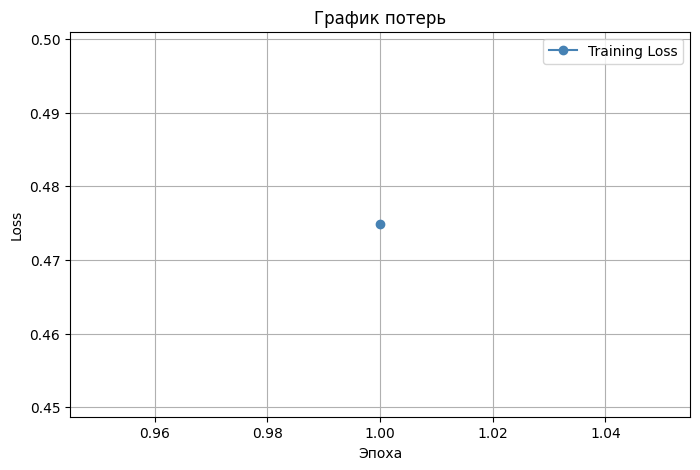

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o",
    color="steelblue",
    label="Training Loss",
)
plt.title("График потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Анализ результатов с mAP
Проанализируем качество с использованием метрики mAP на валидационной выборке:

In [18]:
metric = MeanAveragePrecision(iou_type="bbox")

if os.path.exists("best_model.pth"):
    model.load_state_dict(torch.load("best_model.pth", weights_only=True))

model.eval()
with torch.no_grad():
    for images, targets in val_loader:
        images = list(img.to(device) for img in images)
        outputs = model(images)

        preds = []
        for out in outputs:
            preds.append(
                {
                    "boxes": out["boxes"].cpu(),
                    "scores": out["scores"].cpu(),
                    "labels": out["labels"].cpu(),
                }
            )
        targs = []
        for t in targets:
            targs.append({"boxes": t["boxes"], "labels": t["labels"]})

        metric.update(preds, targs)

results = metric.compute()

print("\nРезультаты (Val)")
print(f"mAP (IoU 0.50-0.95): {results['map'].item()}")
print(f"mAP@50: {results['map_50'].item()}")
print(f"mAP@75: {results['map_75'].item()}")


Результаты (Val)
mAP (IoU 0.50-0.95): 0.7267062067985535
mAP@50: 0.9008994102478027
mAP@75: 0.8162254691123962


## Анализ некоторых кадров

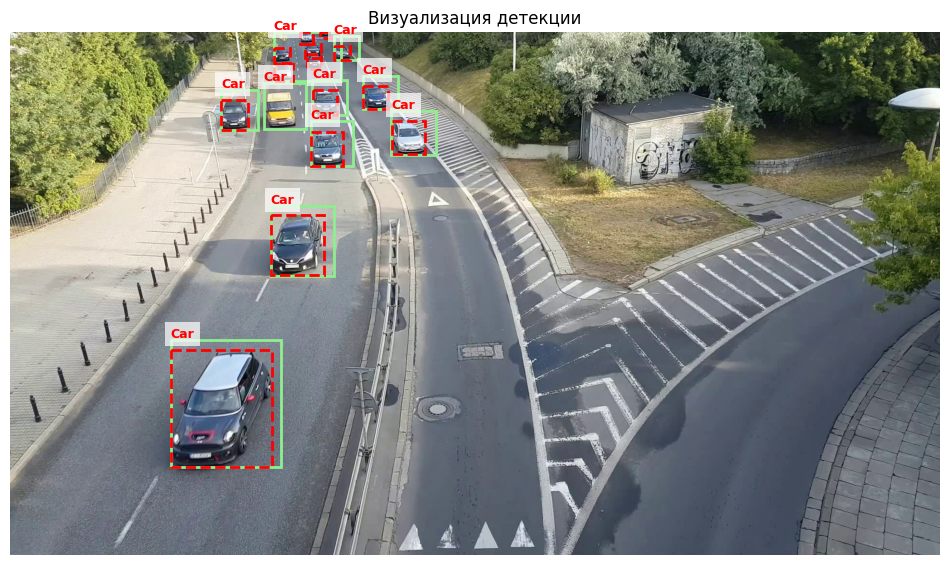

Найдено объектов: 10
Эталонных объектов (зеленые рамки): 14
Средний IoU по всем найденным машинам: 0.4685
Максимальный IoU на кадре: 0.8368


<Figure size 640x480 with 0 Axes>

In [19]:
def get_real_boxes_from_xml(xml_path, frame_number):
    if not os.path.exists(xml_path):
        return []

    tree = ET.parse(xml_path)
    root = tree.getroot()
    real_boxes = []

    for track in root.findall("track"):
        if track.get("label") == "car":
            box = track.find(f".//box[@frame='{frame_number}']")
            if box is not None:
                real_boxes.append(
                    [
                        float(box.get("xtl")),
                        float(box.get("ytl")),
                        float(box.get("xbr")),
                        float(box.get("ybr")),
                    ]
                )

    if not real_boxes:
        for obj in root.findall("object"):
            if obj.find("name").text == "car":
                bbox = obj.find("bndbox")
                real_boxes.append(
                    [
                        float(bbox.find("xmin").text),
                        float(bbox.find("ymin").text),
                        float(bbox.find("xmax").text),
                        float(bbox.find("ymax").text),
                    ]
                )
    return real_boxes

def visualize_predictions(image_np, pred_boxes, gt_boxes=None):
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(image_np)

    for i, box in enumerate(pred_boxes):
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="lightgreen",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, "Car", color='red', fontsize=9, weight='bold',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    if gt_boxes is not None:
        for box in gt_boxes:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
                linestyle="--",
            )
            ax.add_patch(rect)

    ax.axis("off")
    plt.title("Визуализация детекции")
    plt.show()
    plt.tight_layout()

test_frame_idx = 200
frame_path = os.path.join(frames_input, f"frame_{test_frame_idx:04d}.jpg")
annotated_path = os.path.join(frames_output, f"frame_{test_frame_idx:04d}.jpg")

image_bgr = cv2.imread(frame_path)


image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

extracted_boxes = extract_bboxes_my_way(frame_path, annotated_path)
true_boxes = get_real_boxes_from_xml(xml_path, test_frame_idx)

visualize_predictions(image_rgb, pred_boxes=extracted_boxes, gt_boxes=true_boxes)

if true_boxes and extracted_boxes:
    ious = [get_max_iou(b, true_boxes) for b in extracted_boxes]
    avg_iou = sum(ious) / len(ious)

    print(f"Найдено объектов: {len(extracted_boxes)}")
    print(f"Эталонных объектов (зеленые рамки): {len(true_boxes)}")
    print(f"Средний IoU по всем найденным машинам: {avg_iou:.4f}")
    print(f"Максимальный IoU на кадре: {max(ious):.4f}")

## Сборка итогового видео

In [20]:
def create_result_video(input_frames_dir, annotated_frames_dir, output_video_path):

    frames = sorted(os.listdir(input_frames_dir))

    first_frame = cv2.imread(os.path.join(input_frames_dir, frames[0]))
    h, w, _ = first_frame.shape

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    fps = 30.0
    out_video = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

    for frame_name in frames:
        in_path = os.path.join(input_frames_dir, frame_name)
        ann_path = os.path.join(annotated_frames_dir, frame_name)

        img = cv2.imread(in_path)
        bboxes = extract_bboxes_my_way(in_path, ann_path)

        for i, box in enumerate(bboxes):
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.putText(img, "Car", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

        out_video.write(img)

    out_video.release()
    print(f"Видео сохранено по пути: {output_video_path}")

result_path = "final_result.mp4"
create_result_video(frames_input, frames_output, result_path)

Видео сохранено по пути: final_result.mp4


## Выводы
Видим, что границы получились неидеальными: сверху несколько машин часто детектяться как одна, в некоторых местах рамка появляется, хотя не должна, границы рамок тоже далеко не везде совпадают. Для улучшения модели можно попробовать другой способ считывания разметки, увеличить количество эпох.